In [32]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import time

In [17]:
url = "https://api.binance.com/api/v3/depth"
params = {
    "symbol": "BTCUSDT",
    "limit": 10
    }
data = requests.get(url, params=params).json()

In [18]:
pd.DataFrame(data)

,lastUpdateId,bids,asks
0,89890729373,"[69688.15000000, 0.40383000]","[69688.16000000, 2.70225000]"
1,89890729373,"[69688.14000000, 0.00759000]","[69688.17000000, 0.00016000]"
2,89890729373,"[69688.00000000, 0.00184000]","[69688.50000000, 0.00200000]"
3,89890729373,"[69687.99000000, 0.06582000]","[69688.83000000, 0.00016000]"
4,89890729373,"[69687.77000000, 0.00008000]","[69688.84000000, 0.02884000]"
5,89890729373,"[69687.76000000, 0.00170000]","[69688.98000000, 0.00016000]"
6,89890729373,"[69687.75000000, 0.10619000]","[69688.99000000, 0.00733000]"
7,89890729373,"[69687.06000000, 0.00008000]","[69689.00000000, 0.00016000]"
8,89890729373,"[69687.05000000, 0.00008000]","[69689.01000000, 0.08499000]"
9,89890729373,"[69686.66000000, 0.00016000]","[69689.02000000, 0.00116000]"


In [19]:
data

{'lastUpdateId': 89890729373,
 'bids': [['69688.15000000', '0.40383000'],
  ['69688.14000000', '0.00759000'],
  ['69688.00000000', '0.00184000'],
  ['69687.99000000', '0.06582000'],
  ['69687.77000000', '0.00008000'],
  ['69687.76000000', '0.00170000'],
  ['69687.75000000', '0.10619000'],
  ['69687.06000000', '0.00008000'],
  ['69687.05000000', '0.00008000'],
  ['69686.66000000', '0.00016000']],
 'asks': [['69688.16000000', '2.70225000'],
  ['69688.17000000', '0.00016000'],
  ['69688.50000000', '0.00200000'],
  ['69688.83000000', '0.00016000'],
  ['69688.84000000', '0.02884000'],
  ['69688.98000000', '0.00016000'],
  ['69688.99000000', '0.00733000'],
  ['69689.00000000', '0.00016000'],
  ['69689.01000000', '0.08499000'],
  ['69689.02000000', '0.00116000']]}

In [20]:
data['bids'][:3]

[['69688.15000000', '0.40383000'],
 ['69688.14000000', '0.00759000'],
 ['69688.00000000', '0.00184000']]

In [21]:
data['asks'][:3]

[['69688.16000000', '2.70225000'],
 ['69688.17000000', '0.00016000'],
 ['69688.50000000', '0.00200000']]

In [31]:
best_bid = float(data['bids'][0][0])
best_ask = float(data['asks'][0][0])
spread = best_ask - best_bid
mid_price = (best_bid + best_ask)/2

print(f"Best Bid: {best_bid}\nBest Ask: {best_ask}")
print(f"Spread: {spread}")
print(f"Mid Price: {mid_price}")


Best Bid: 69688.15
Best Ask: 69688.16
Spread: 0.010000000009313226
Mid Price: 69688.155


Build a Simple Data Collector for 1 minute Market Data

In [72]:
rows = [] # Create an empty list to store the rows of the DataFrame

for _ in range(60):
    url = "https://api.binance.com/api/v3/depth"
    params = {
        "symbol": "BTCUSDT",
        "limit": 10
    }

    data = requests.get(url, params=params).json()

    best_bid = float(data['bids'][0][0])
    best_ask = float(data['asks'][0][0])
    
    spread = best_ask - best_bid
    mid_price = (best_bid + best_ask)/2
    
    timestamp = time.time()

    bid_volume = float(data['bids'][0][1])
    ask_volume = float(data['asks'][0][1])
    imbalance = (bid_volume - ask_volume) / (bid_volume + ask_volume)
    

    rows.append([timestamp, best_bid, best_ask, spread, mid_price, imbalance]) # Append the row to the list
    time.sleep(1) # Sleep for 1 second before the next iteration


df = pd.DataFrame(rows, columns = ['timestamp', 'best_bid', 'best_ask', 'spread', 'mid_price', 'imbalance']) # Create a DataFrame from the list of rows
df["timestamp"] = pd.to_datetime(df["timestamp"], unit='s').dt.floor('s') # Convert timestamp to datetime

print(df)

             timestamp  best_bid  best_ask  spread  mid_price  imbalance
0  2026-03-11 17:48:58  70843.83  70843.84    0.01  70843.835   0.695446
1  2026-03-11 17:48:59  70843.83  70843.84    0.01  70843.835   0.575027
2  2026-03-11 17:49:01  70843.83  70843.84    0.01  70843.835   0.662326
3  2026-03-11 17:49:02  70847.61  70847.62    0.01  70847.615   0.801854
4  2026-03-11 17:49:03  70838.87  70838.88    0.01  70838.875  -0.997654
5  2026-03-11 17:49:04  70824.00  70824.01    0.01  70824.005  -0.998559
6  2026-03-11 17:49:05  70817.12  70817.13    0.01  70817.125   0.938079
7  2026-03-11 17:49:07  70822.90  70822.91    0.01  70822.905   0.110433
8  2026-03-11 17:49:08  70810.04  70810.05    0.01  70810.045  -0.572329
9  2026-03-11 17:49:09  70810.04  70810.05    0.01  70810.045  -0.161554
10 2026-03-11 17:49:10  70816.00  70816.01    0.01  70816.005  -0.995085
11 2026-03-11 17:49:11  70807.50  70807.51    0.01  70807.505   0.523535
12 2026-03-11 17:49:13  70807.50  70807.51    0.01 

In [73]:
df.head()

,timestamp,best_bid,best_ask,spread,mid_price,imbalance
0,2026-03-11 17:48:58,70843.83,70843.84,0.01,70843.835,0.695446
1,2026-03-11 17:48:59,70843.83,70843.84,0.01,70843.835,0.575027
2,2026-03-11 17:49:01,70843.83,70843.84,0.01,70843.835,0.662326
3,2026-03-11 17:49:02,70847.61,70847.62,0.01,70847.615,0.801854
4,2026-03-11 17:49:03,70838.87,70838.88,0.01,70838.875,-0.997654


Saving the Dataset as a CSV file

In [74]:
df.to_csv("../data/orderbook_data.csv", index=False) # Save the DataFrame to a CSV file without the index

Visualize Midprice

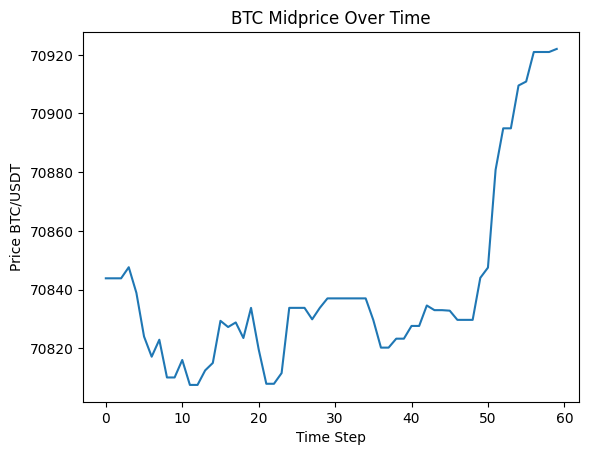

In [75]:
plt.plot(df['mid_price'])
plt.title("BTC Midprice Over Time")
plt.xlabel("Time Step")
plt.ylabel("Price BTC/USDT")
plt.show()

Visualize Spread

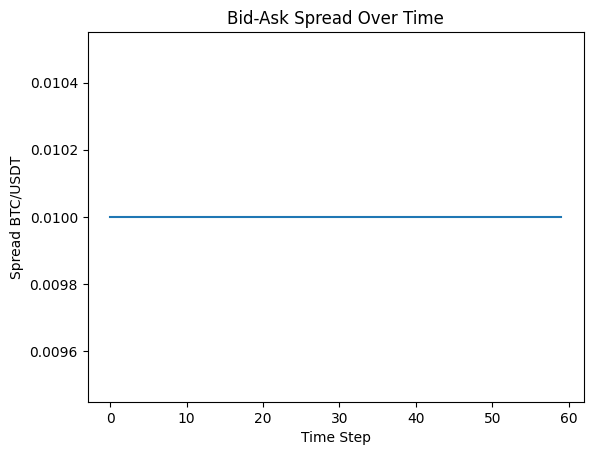

In [81]:
df['spread'] = df['spread'].round(4)
plt.plot(df['spread'])
plt.title("Bid-Ask Spread Over Time")
plt.xlabel("Time Step")
plt.ylabel("Spread BTC/USDT")
plt.show()

Visualize Imbalance

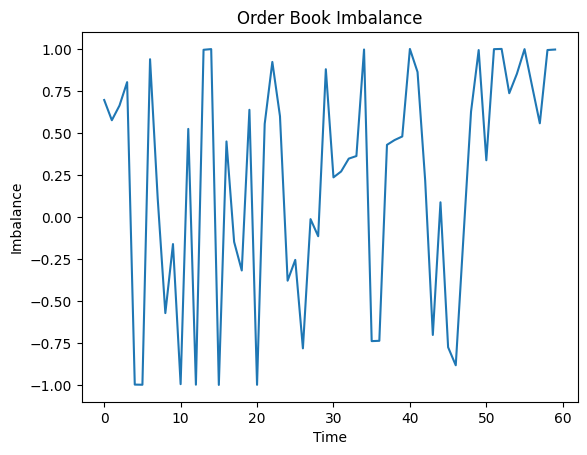

In [82]:
plt.plot(df["imbalance"])
plt.title("Order Book Imbalance")
plt.xlabel("Time")
plt.ylabel("Imbalance")
plt.show()

plt.figure(figsize=(10, 8))
plt.subplot(2,1,1)
plt.plot(df['mid_price'])
plt.title('Midprice')

plt.subplot(2,1,2)
plt.plot(df['imbalance'])
plt.title('Order Book Imbalance')

plt.show()

In [ ]:
df['imbalance'].nlargest(5) # Buy pressure

52    0.999372
40    0.999343
14    0.998274
55    0.998109
51    0.997966
Name: imbalance, dtype: float64

In [88]:
df['imbalance'].nsmallest(5) # Sell pressure

15   -0.999599
20   -0.998967
5    -0.998559
12   -0.998236
4    -0.997654
Name: imbalance, dtype: float64

In [91]:
top = df.sort_values("imbalance", ascending=False).head(5)

In [95]:
print(top[['timestamp', 'imbalance', 'mid_price']])
# print(top['timestamp', 'imbalance', 'mid_price'])



             timestamp  imbalance  mid_price
52 2026-03-11 17:50:02   0.999372  70894.945
40 2026-03-11 17:49:48   0.999343  70827.605
14 2026-03-11 17:49:15   0.998274  70814.995
55 2026-03-11 17:50:06   0.998109  70910.885
51 2026-03-11 17:50:01   0.997966  70880.805


Adding Microprice